# NCAA forecasting | achieved release and research judgment
**Alvaro Mendizabal · employer-facing ML engineering case study**

A recorded late-submission Brier of **0.1094899** is numerically below the published 2026 winning benchmark of **0.1097454**. This is not an original first-place finish. The notebook renders approved aggregates only; it does not distribute or execute the forecasting system.

In [1]:
from pathlib import Path
import sys
root=Path.cwd()
if not (root/'portfolio').is_dir(): root=root.parent
sys.path.insert(0,str(root/'portfolio'))
from current_research import load,chart
import pandas as pd
from IPython.display import display
d=load();s=d['scored'];w=d['women_historical']
display(pd.DataFrame([{'Release':'Retained champion','Brier':s['champion'],'Status':'Scored'}, {'Release':'Women extension','Brier':s['women_candidate'],'Status':'Scored; rejected'}]))

,Release,Brier,Status
0,Retained champion,0.109490,Scored
1,Women extension,0.110524,Scored; rejected


## 1. The achieved result and the rejected extension
The existing men’s margin-based release improved the predecessor. A later women’s extension had encouraging historical results, but its recorded late score was **0.1105237**, worse by **0.0010338**. It was rejected; the **0.1094899** champion is unchanged. These three observations belong to post-competition scoring, not a new prospective trial.

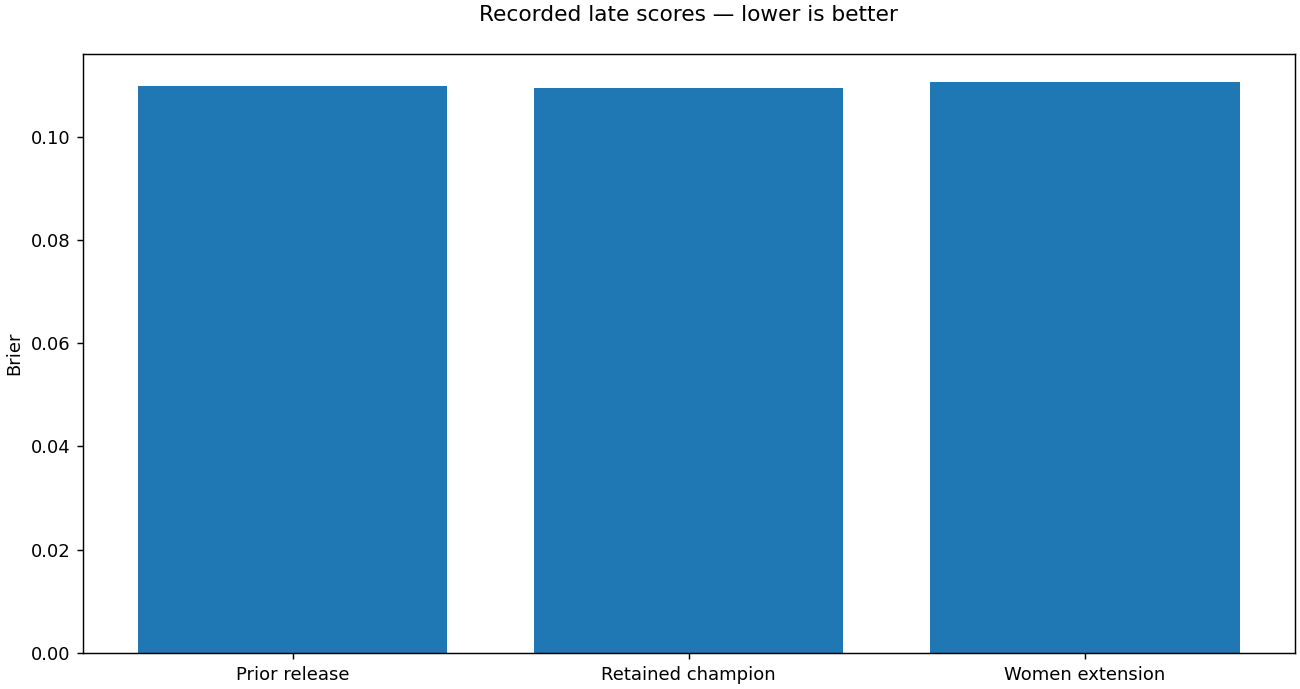

Published benchmark: 0.1097454
Champion below benchmark: 0.0002555


In [2]:
chart('release_scores','Recorded late scores — lower is better',['Prior release','Retained champion','Women extension'],{'Brier':[s['predecessor'],s['champion'],s['women_candidate']]},'Brier')
print('Published benchmark:',s['benchmark'])
print('Champion below benchmark:',round(s['benchmark']-s['champion'],7))

## 2. More features were not automatically better
Several plausible approaches were tested and rejected. Learning actual score margins gave the auxiliary information a different role and produced a useful men’s ensemble. Selection results from a win/loss model cannot establish that selection is exhausted for a different objective. The next private question is model-specific rather than another blanket claim about thousands of columns.

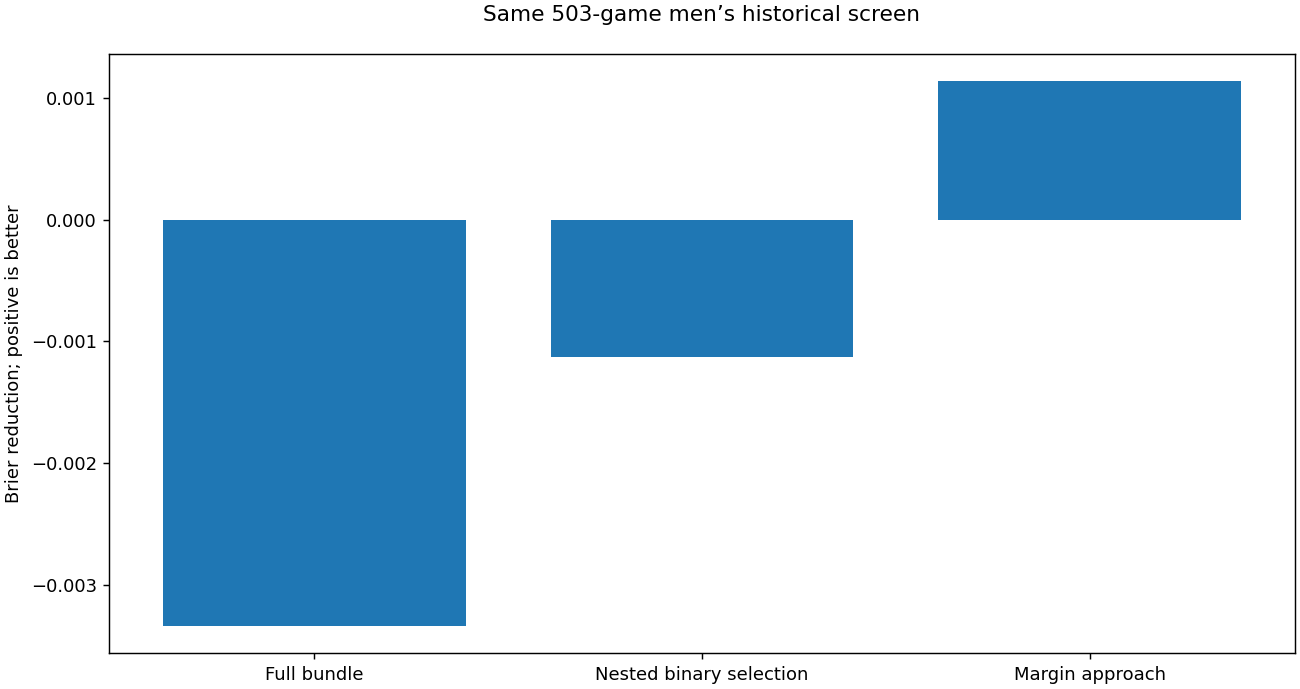

In [3]:
m=d['men_historical']
chart('men_research','Same 503-game men’s historical screen',['Full bundle','Nested binary selection','Margin approach'],{'Gain vs screening core':[m['core']-m['full_feature_fusion'],m['core']-m['nested_binary_selection'],m['core']-m['margin_blend']]},'Brier reduction; positive is better')

## 3. Why validation and actual scoring must remain separate
The women’s robustness result improved on the same 189 historical main-bracket games from 2023–2025. Whole-year exclusion, matched targets and fixed random repeats constrained the experiment, but these were reused development years. The later score did not validate a gain. No single cause is established without further evidence.

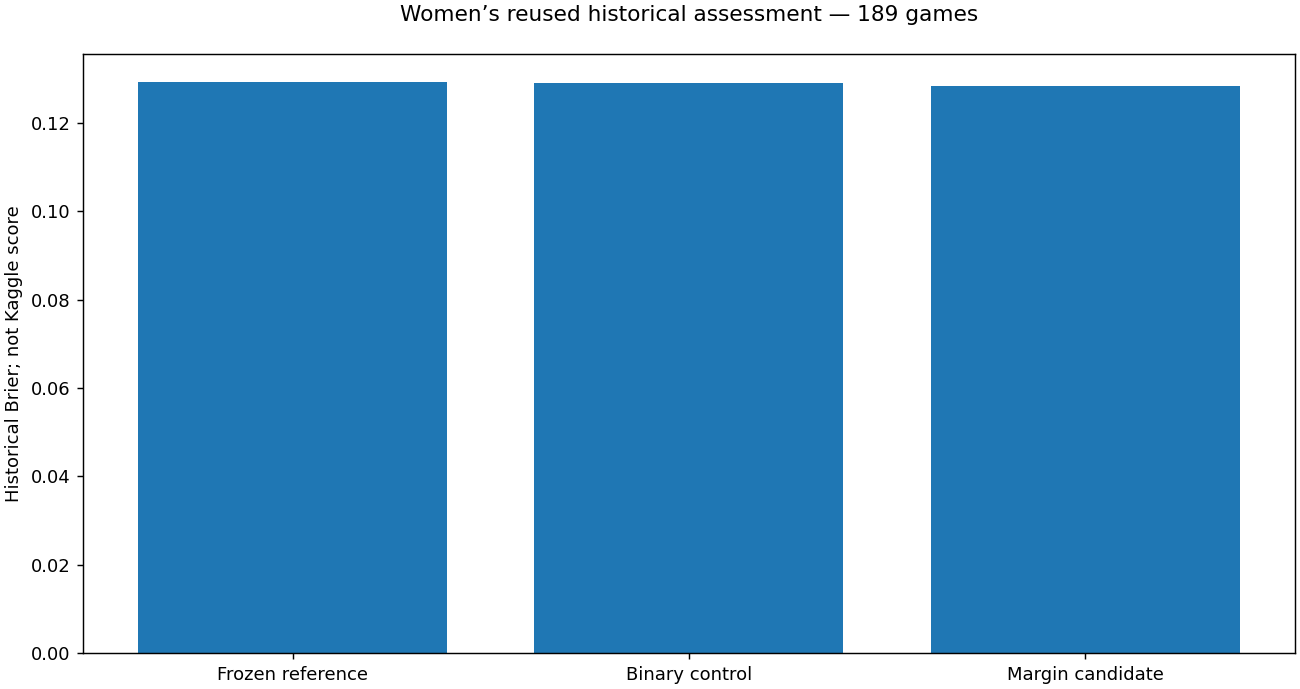

In [4]:
chart('women_historical','Women’s reused historical assessment — 189 games',['Frozen reference','Binary control','Margin candidate'],{'Brier':[w['core'],w['binary'],w['margin']]},'Historical Brier; not Kaggle score')

,year,core,binary,margin
0,2023,0.179331,0.180774,0.177769
1,2024,0.115484,0.115215,0.114968
2,2025,0.092826,0.090990,0.092182


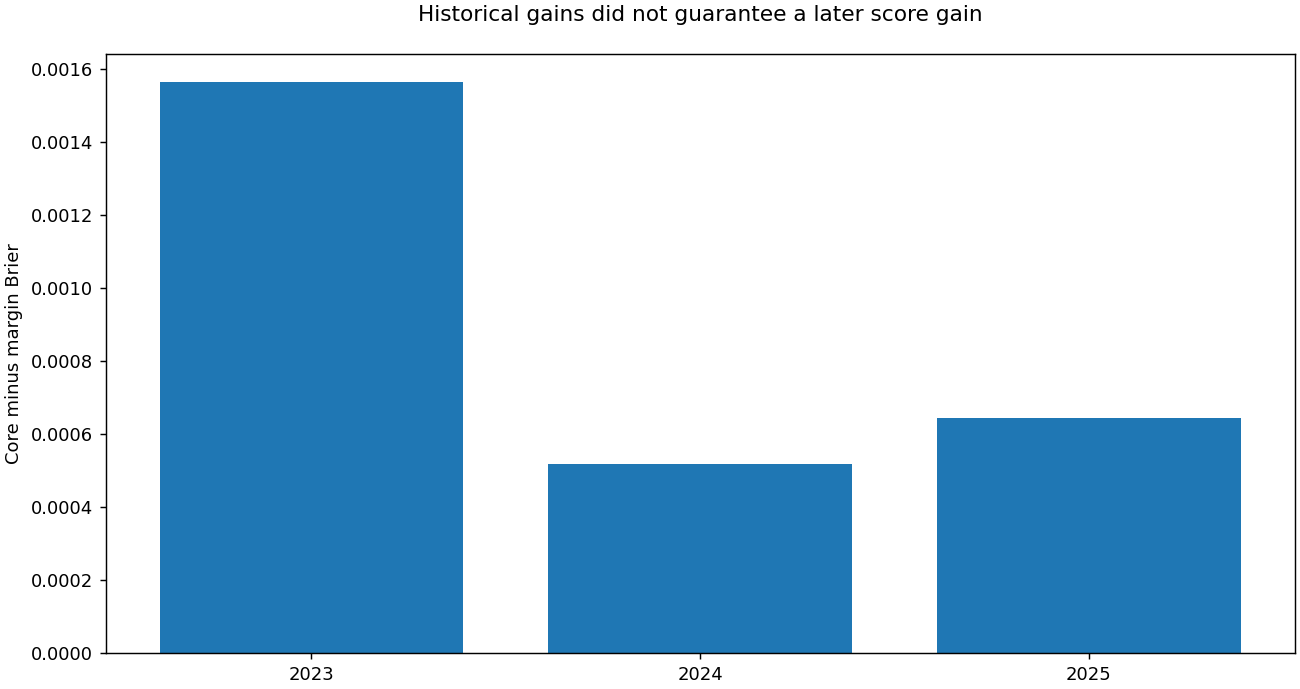

In [5]:
years=pd.DataFrame(w['years'])
display(years)
chart('women_years','Historical gains did not guarantee a later score gain',years.year.tolist(),{'Gain vs reference':(years.core-years.margin).tolist()},'Core minus margin Brier')

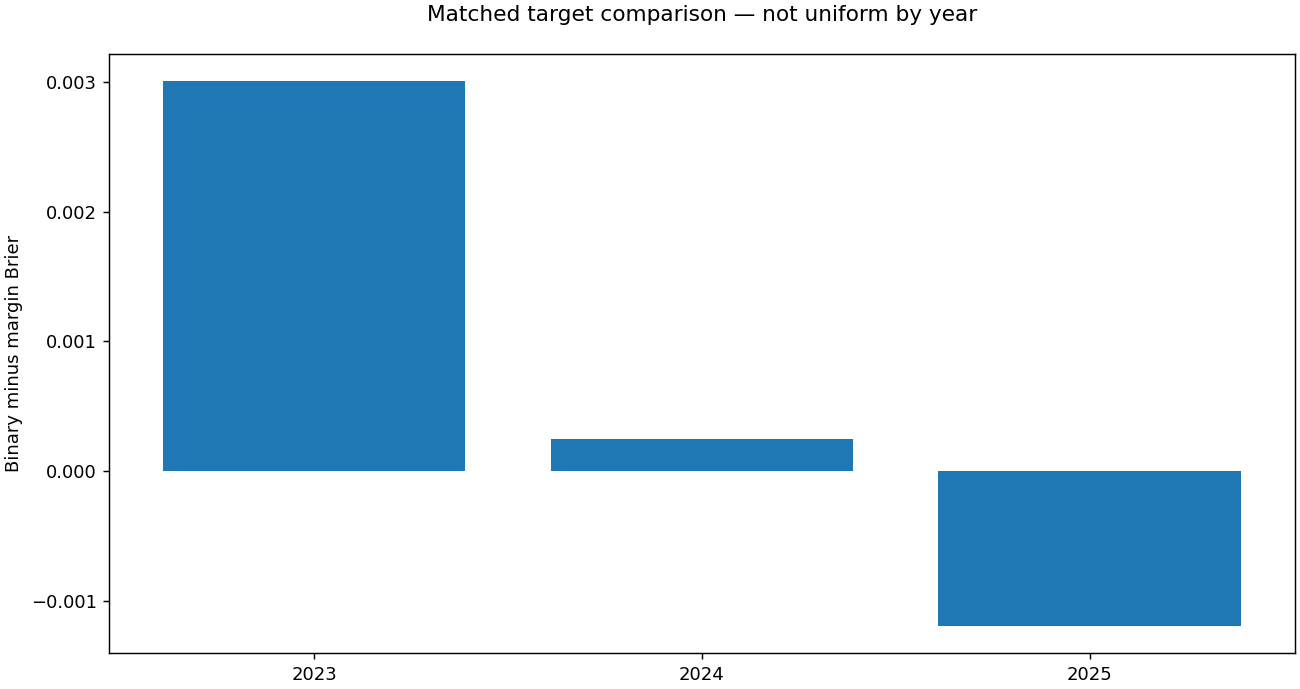

In [6]:
chart('women_target_control','Matched target comparison — not uniform by year',years.year.tolist(),{'Margin advantage':(years.binary-years.margin).tolist()},'Binary minus margin Brier')

## 4. Engineering protected the achieved release
Only 2,278 women’s matchup lines changed in the rejected candidate. All 66,430 men’s lines and 129,855 total protected lines were identical. The latest replay reused all 45 candidate models, made zero new fits and zero new uploads, and recovered the existing score. A negative scientific outcome is not an execution crash.

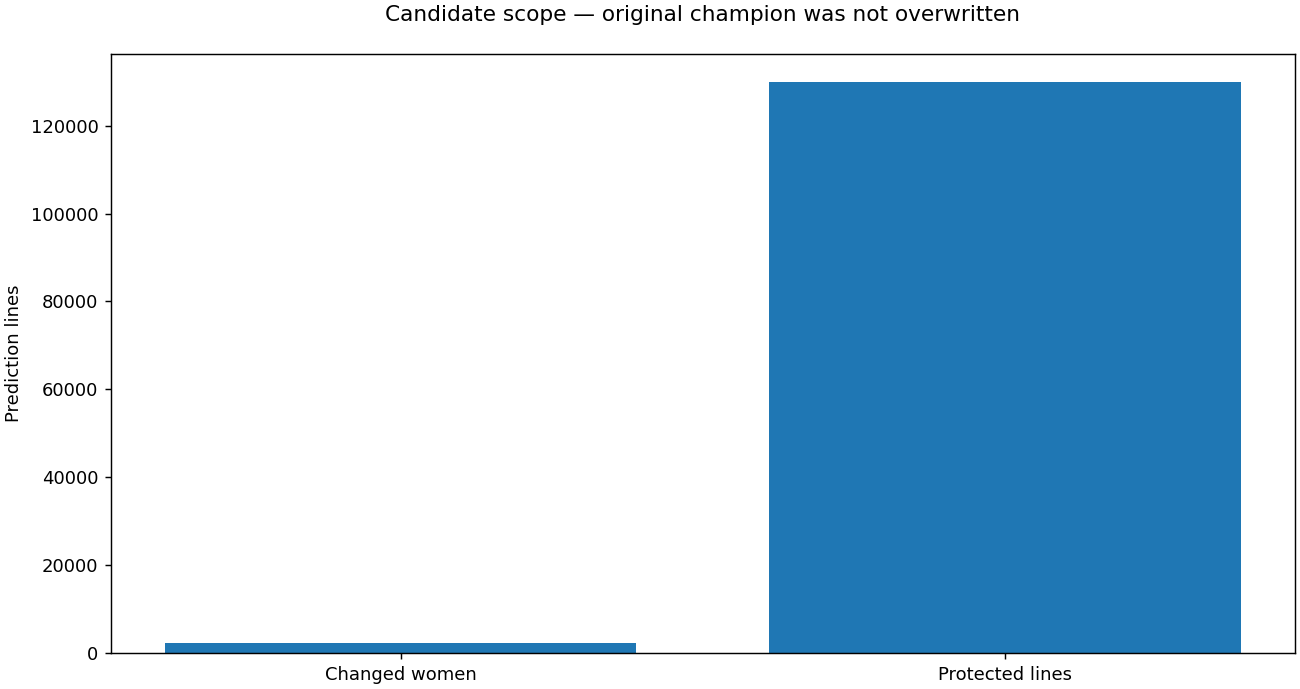

,run_id,new_tree_fits,reused_tree_fits,new_submissions,elapsed_seconds,inventory_verified
0,20260922T163620151512Z-533,0,45,0,23.08,33


In [7]:
p=d['preservation']
chart('protected_rows','Candidate scope — original champion was not overwritten',['Changed women','Protected lines'],{'CSV lines':[p['changed_women_rows'],p['protected_rows']]},'Prediction lines')
display(pd.DataFrame([d['replay']]))

## 5. What remains unresolved
The work is a benchmark-informed applied ML result, not evidence of universal state-of-the-art performance. Top-solution coverage is not complete. Dated external information, richer representations and objective-specific selection remain research questions. A lower 2026 late score is not proof of a 2027 advantage. Future forecasts need timestamped input snapshots and a frozen evaluation protocol.

Inner held-out predictions informed both early stopping and calibration; previous research reused the outer years. Additional random repeats do not create independent tournaments. No 0.09 result is claimed or implied.

## 6. Ownership and public scope
Public material demonstrates the result, reasoning, controls and engineering. The current detailed implementation, feature definitions, tuning recipes and model files stay outside this publication. Previously published source and license terms still exist; this update does not erase history.

The compact reference is attributed to Harrison Horan’s public first-place solution. The retained score is supported by submission identity and prediction hashes in the aggregate evidence. Private repeatability is preserved for the owner, without adding a public retraining kit.

In [8]:
print('Release decision:',s['decision'])
print('New score produced by this report:',None)
print('REPORT_COMPLETE — approved aggregates; no training or submission')

Release decision: KEEP_CHAMPION_REJECT_WOMEN
New score produced by this report: None
REPORT_COMPLETE — approved aggregates; no training or submission
